# Predicting Patient Copay Using Medicare Pricing Data

## 1. Business Understanding

The goal of this project is to explore the relationship between Medicare pricing and patient copay values, and to build a model that predicts copay for new patients.

This project follows the CRISP-DM process:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## 2. Data Understanding

In this step, the dataset is explored to understand its structure, variables, and overall quality before building the model.

In [24]:
df = pd.read_csv("Physical_Therapist_in_Private_Practice.csv")
df.head()

,zip_code,min_medicare_pricing_for_new_patient,max_medicare_pricing_for_new_patient,mode_medicare_pricing_for_new_patient,min_copay_for_new_patient,max_copay_for_new_patient,mode_copay_for_new_patient,most_utilized_procedure_code_for_new_patient,min_medicare_pricing_for_established_patient,max_medicare_pricing_for_established_patient,mode_medicare_pricing_for_established_patient,min_copay_for_established_patient,max_copay_for_established_patient,mode_copay_for_established_patient,most_utilized_procedure_code_for_established_patient
0,210,57.752,174.264,89.144,14.438,43.566,22.286,99203,18.704,142.152,71.856,4.676,35.538,17.964,99213
1,211,57.752,174.264,89.144,14.438,43.566,22.286,99203,18.704,142.152,71.856,4.676,35.538,17.964,99213
2,212,57.752,174.264,89.144,14.438,43.566,22.286,99203,18.704,142.152,71.856,4.676,35.538,17.964,99213
3,213,57.752,174.264,89.144,14.438,43.566,22.286,99203,18.704,142.152,71.856,4.676,35.538,17.964,99213
4,214,57.752,174.264,89.144,14.438,43.566,22.286,99203,18.704,142.152,71.856,4.676,35.538,17.964,99213


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42966 entries, 0 to 42965
Data columns (total 15 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   zip_code                                              42966 non-null  int64  
 1   min_medicare_pricing_for_new_patient                  42966 non-null  float64
 2   max_medicare_pricing_for_new_patient                  42966 non-null  float64
 3   mode_medicare_pricing_for_new_patient                 42966 non-null  float64
 4   min_copay_for_new_patient                             42966 non-null  float64
 5   max_copay_for_new_patient                             42966 non-null  float64
 6   mode_copay_for_new_patient                            42966 non-null  float64
 7   most_utilized_procedure_code_for_new_patient          42966 non-null  int64  
 8   min_medicare_pricing_for_established_patient          42966 non-nul

In [26]:
df.columns

Index(['zip_code', 'min_medicare_pricing_for_new_patient',
       'max_medicare_pricing_for_new_patient',
       'mode_medicare_pricing_for_new_patient', 'min_copay_for_new_patient',
       'max_copay_for_new_patient', 'mode_copay_for_new_patient',
       'most_utilized_procedure_code_for_new_patient',
       'min_medicare_pricing_for_established_patient',
       'max_medicare_pricing_for_established_patient',
       'mode_medicare_pricing_for_established_patient',
       'min_copay_for_established_patient',
       'max_copay_for_established_patient',
       'mode_copay_for_established_patient',
       'most_utilized_procedure_code_for_established_patient'],
      dtype='str')

In [27]:
df.describe()

,zip_code,min_medicare_pricing_for_new_patient,max_medicare_pricing_for_new_patient,mode_medicare_pricing_for_new_patient,min_copay_for_new_patient,max_copay_for_new_patient,mode_copay_for_new_patient,most_utilized_procedure_code_for_new_patient,min_medicare_pricing_for_established_patient,max_medicare_pricing_for_established_patient,mode_medicare_pricing_for_established_patient,min_copay_for_established_patient,max_copay_for_established_patient,mode_copay_for_established_patient,most_utilized_procedure_code_for_established_patient
count,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.0,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.0
mean,49592.582973,56.037691,170.408565,86.817184,14.009423,42.602141,21.704296,99203.0,17.913046,138.884824,69.988244,4.478261,34.721206,17.497061,99213.0
std,27972.379592,3.802850,10.434525,5.658985,0.950713,2.608631,1.414746,0.0,1.450066,8.516998,4.490030,0.362516,2.129250,1.122507,0.0
min,210.000000,51.360000,157.744000,79.728000,12.840000,39.436000,19.932000,99203.0,16.152000,128.776000,64.560000,4.038000,32.194000,16.140000,99213.0
25%,26039.250000,53.264000,163.240000,82.928000,13.316000,40.810000,20.732000,99203.0,16.912000,133.296000,66.848000,4.228000,33.324000,16.712000,99213.0
50%,48818.500000,54.848000,166.888000,84.928000,13.712000,41.722000,21.232000,99203.0,17.528000,136.112000,68.552000,4.382000,34.028000,17.138000,99213.0
75%,73040.750000,57.272000,173.088000,88.376000,14.318000,43.272000,22.094000,99203.0,18.448000,141.112000,71.296000,4.612000,35.278000,17.824000,99213.0
max,99950.000000,71.336000,222.640000,111.576000,17.834000,55.660000,27.894000,99203.0,24.016000,181.480000,90.408000,6.004000,45.370000,22.602000,99213.0


### Initial Observations

- The dataset contains 42,966 rows and 15 columns.
- All variables are numerical.
- There are no missing values in the dataset.
- Some columns, such as the procedure code columns, appear to have no variation and may not be useful for modeling.

## 3. Business Questions and Analysis

The following questions are used to guide the analysis in a real-world context.

### Question 1: How are Medicare pricing values distributed for new patients?

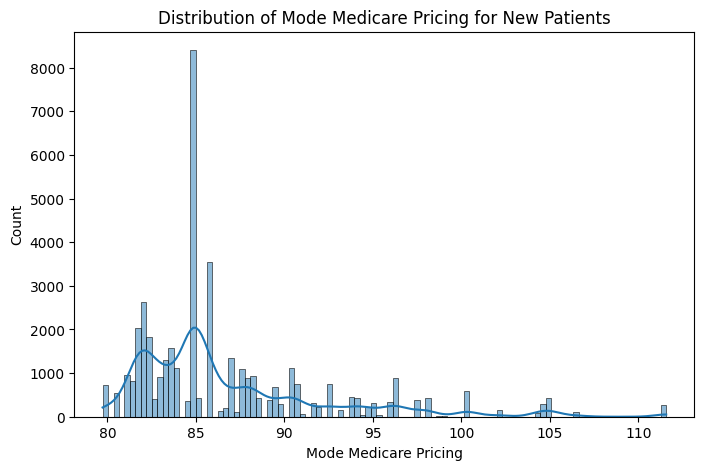

In [41]:
def plot_medicare_pricing_distribution(df):
    """
    This function plots the distribution of Medicare pricing for new patients.

    Input:
        df: pandas DataFrame containing the column 
            'mode_medicare_pricing_for_new_patient'

    Output:
        A histogram plot with KDE showing the distribution of Medicare pricing
    """
  
    plt.figure(figsize=(8,5))
    sns.histplot(df['mode_medicare_pricing_for_new_patient'], kde=True)
    plt.title("Distribution of Mode Medicare Pricing for New Patients")
    plt.xlabel("Mode Medicare Pricing")
    plt.ylabel("Count")
    plt.show()

plot_medicare_pricing_distribution(df)

Most values are concentrated in the lower range, while fewer observations appear at higher values. This indicates a right-skewed distribution.

### Question 2: How are copay values distributed for new patients?

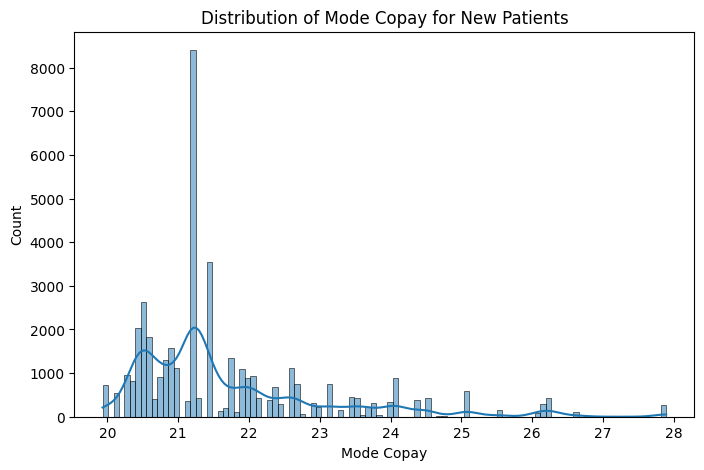

In [42]:
def plot_copay_distribution(df):
    """
    This function plots the distribution of copay for new patients.

    Input:
        df: pandas DataFrame containing the column 
            'mode_copay_for_new_patient'

    Output:
        A histogram plot with KDE showing the distribution of copay values
    """

    plt.figure(figsize=(8,5))
    sns.histplot(df['mode_copay_for_new_patient'], kde=True)
    plt.title("Distribution of Mode Copay for New Patients")
    plt.xlabel("Mode Copay")
    plt.ylabel("Count")
    plt.show()

plot_copay_distribution(df)

The copay values also show a right-skewed distribution. This means that most clinics have lower to moderate copay values, while fewer clinics have higher copay amounts.

### Question 3: What is the relationship between Medicare pricing and copay for new patients?

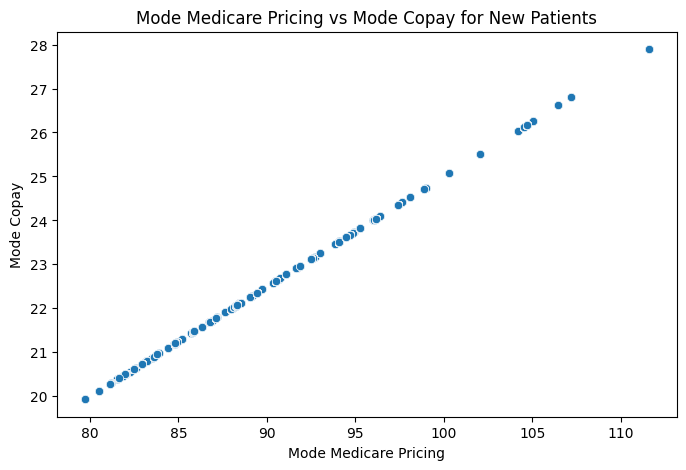

In [43]:
def plot_medicare_vs_copay(df):
    """
    This function creates a scatter plot to show the relationship 
    between Medicare pricing and copay for new patients.

    Input:
        df: pandas DataFrame containing the columns 
            'mode_medicare_pricing_for_new_patient' and 
            'mode_copay_for_new_patient'

    Output:
        A scatter plot showing the relationship between Medicare pricing and copay
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8,5))
    sns.scatterplot(
        x='mode_medicare_pricing_for_new_patient',
        y='mode_copay_for_new_patient',
        data=df
    )
    plt.title("Mode Medicare Pricing vs Mode Copay for New Patients")
    plt.xlabel("Mode Medicare Pricing")
    plt.ylabel("Mode Copay")
    plt.show()

plot_medicare_vs_copay(df)

The scatterplot shows a strong positive relationship between pricing and copay. As Medicare pricing increases, copay tends to increase as well.

### Question 4: Which variables are most strongly related to copay values?

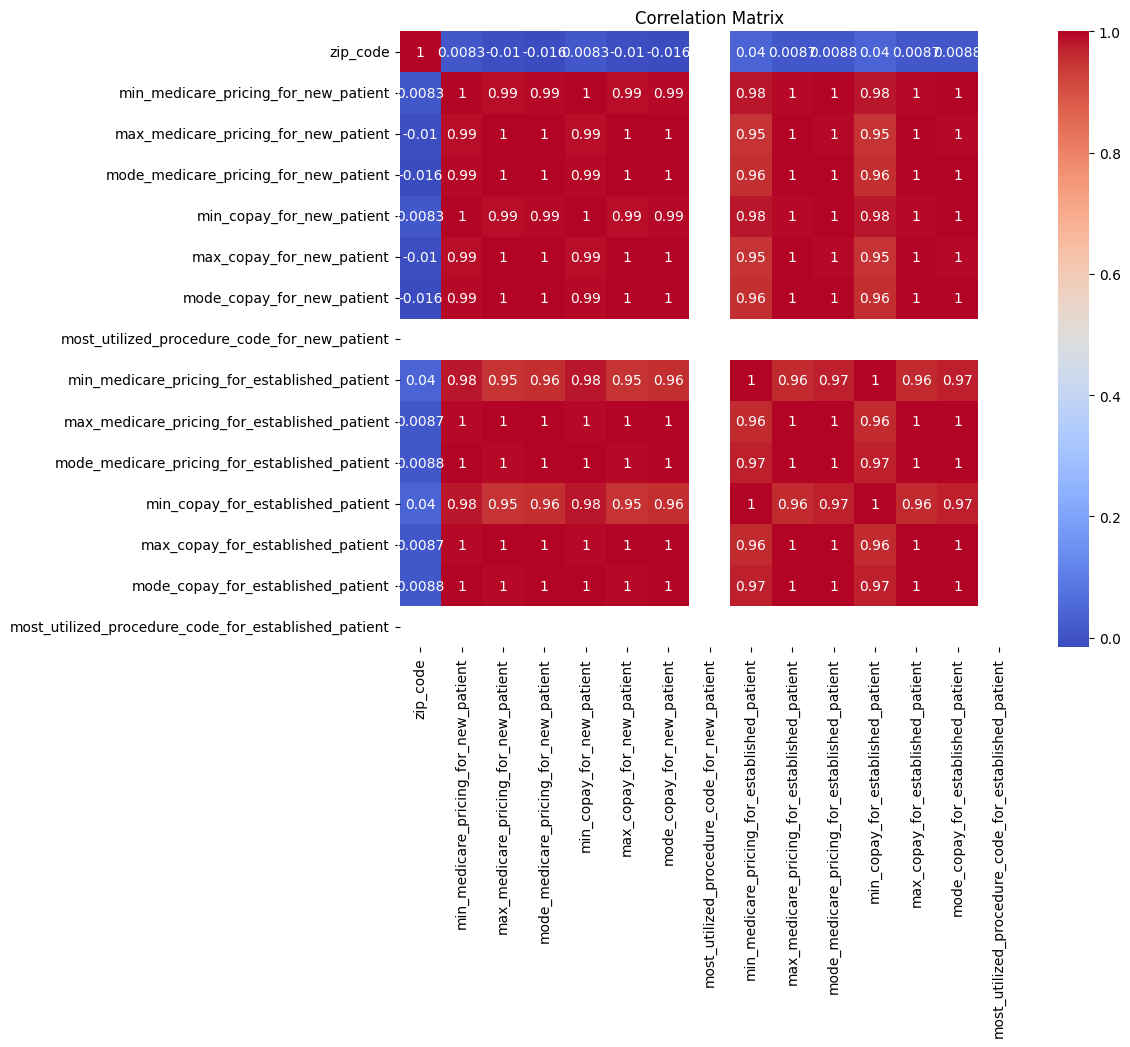

In [44]:
def plot_correlation_matrix(df):
    """
    This function computes and visualizes the correlation matrix 
    of a dataframe using a heatmap.

    Input:
        df: pandas DataFrame with numerical features

    Output:
        A heatmap showing the correlation between variables
    """

    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()

plot_correlation_matrix(df)

The correlation matrix shows that copay variables are strongly related to pricing variables, especially for the same patient type. This suggests that pricing features are useful predictors for a regression model.

## 4. Data Preparation

Based on the analysis, only the pricing features related to new patients will be used to predict the copay for new patients.

In [32]:
features = [
    'min_medicare_pricing_for_new_patient',
    'max_medicare_pricing_for_new_patient',
    'mode_medicare_pricing_for_new_patient'
]

target = 'mode_copay_for_new_patient'

X = df[features]
y = df[target]

The selected features are directly related to Medicare pricing for new patients. Other variables were not used in the model because the project is focused specifically on predicting new patient copay.

### Handling Missing and Categorical Values

There are no missing values in this dataset, so no imputation was needed.

There are also no categorical variables, since all columns are already numerical. Because of this, no encoding techniques such as one-hot encoding were required.

## 5. Modeling

A Linear Regression model is used because the target variable is continuous, and the goal is to predict a numerical copay value.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
y_pred = model.predict(X_test)

## 6. Evaluation

The model is evaluated using Mean Absolute Error (MAE) and R² score.
- MAE measures the average prediction error.
- R² score shows how well the model explains the variation in the target variable.

In [36]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 3.7122840162472072e-16
R2 Score: 1.0


The model achieved extremely high performance, with an R² score of 1.0 and an almost zero MAE.

This suggests that the relationship between pricing and copay is very strong in this dataset, and the target variable is likely directly derived from the pricing values.

## 7. Model Interpretation

In [37]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,min_medicare_pricing_for_new_patient,1.864288e-16
1,max_medicare_pricing_for_new_patient,-1.387779e-17
2,mode_medicare_pricing_for_new_patient,2.500000e-01


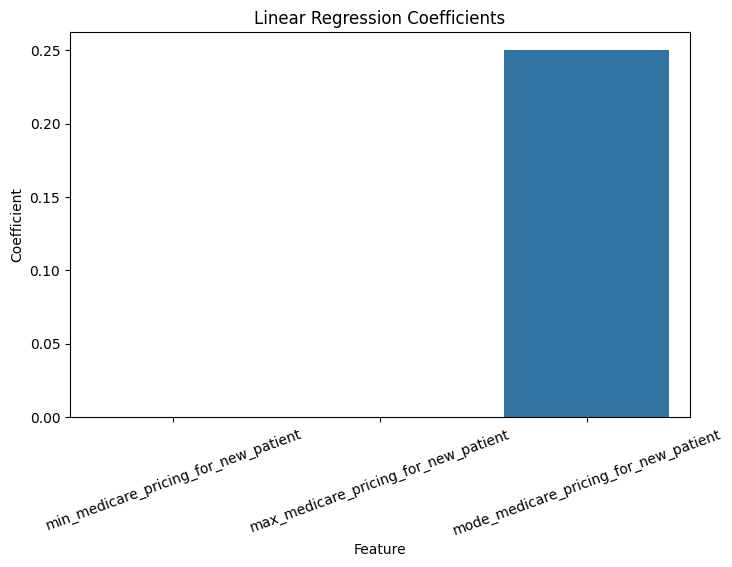

In [46]:
def plot_regression_coefficients(coefficients):
    """
    This function plots the coefficients of a linear regression model.

    Input:
        coefficients: pandas DataFrame containing:
            - 'Feature': feature names
            - 'Coefficient': corresponding coefficient values

    Output:
        A bar plot showing the importance of each feature based on coefficients
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8,5))
    sns.barplot(data=coefficients, x='Feature', y='Coefficient')
    plt.title("Linear Regression Coefficients")
    plt.xticks(rotation=20)
    plt.show()


plot_regression_coefficients(coefficients)

### Interpreting the Model Coefficients

From the plot, the features do not all contribute in the same way to the prediction.

It appears that the **mode Medicare pricing** has a larger influence compared to the other features. The minimum and maximum pricing values seem to have a smaller effect on the model’s output.

This suggests that the model tends to rely more on the most common price (mode) when estimating the copay. In other words, the typical price used by a clinic seems to play a noticeable role in the prediction.

This may also help explain the high model performance, since the copay values appear to be closely related to this pricing feature.


## 8. Example Prediction

A practical example is used below to show how the model can estimate copay for a new patient based on pricing values.

In [39]:
sample = np.array([[60, 180, 95]])
prediction = model.predict(sample)

print("Predicted Copay:", prediction[0])

Predicted Copay: 23.75


c:\Users\lyane\OneDrive\Desktop\DataScience\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Conclusion

In this project, we explored the relationship between Medicare pricing and patient copay for new patients.

The results showed a clear connection between pricing and copay, with the model performing very well. It also appeared that the most common pricing value plays an important role in predicting the copay.

Overall, the findings suggest that pricing is a key factor in estimating patient payments in this dataset.
